In [1]:
import pandas as pd
import numpy as np
import os
import gc

# --- 1. 配置與檢查區域 ---
FILE_NAME = 'PS_20174392719_1491204439457_log.csv'

def aml_feature_engineering_full(df):
    """
    AML AI Investigator - 偵測模組 (完整版特徵工程)
    整合所有合規紅旗指標：C2C 識別、資金掏空、整數交易、餘額不匹配
    """
    
    # [A] 身份識別邏輯 (必須在 drop 之前執行)
    # 利用 PaySim 原始 ID 首字母判斷角色：C (Customer), M (Merchant)
    # 銀行合規最關注 C2C (個人轉個人) 的異常轉賬
    if 'nameOrig' in df.columns and 'nameDest' in df.columns:
        df['is_C2C'] = ((df['nameOrig'].str.startswith('C')) & 
                        (df['nameDest'].str.startswith('C'))).astype(np.int8)
    
    # [B] 核心合規紅旗特徵 (Red Flags)
    
    # 1. 資金掏空比例 (Transfer Intensity)
    # 1.0 表示全額轉走。洗錢分子常用手段
    df['amount_orig_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1e-5) 

    # 2. 異常餘額變動 (The "Ghost" Balance)
    # 正常交易：DestNew - DestOld = Amount。如果不等於，代表數據有隱藏流向或系統繞過
    df['dest_balance_diff'] = (df['newbalanceDest'] - df['oldbalanceDest']) - df['amount']
    df['is_dest_imbalance'] = (abs(df['dest_balance_diff']) > 0.01).astype(np.int8)

    # 3. 整數交易偵測 (Round Amount)
    # 標記如 1000, 50000 等整數交易，這在洗錢偵測中比消費行為更常見
    df['is_round_amount'] = (df['amount'] % 1000 == 0).astype(np.int8)

    # 4. 結構化交易 (Structuring) 
    # 標記接近 HKMA 監管閾值 (500,000) 的規避行為
    threshold = 500000
    df['is_near_threshold'] = ((df['amount'] > threshold * 0.9) & (df['amount'] <= threshold)).astype(np.int8)

    # [C] 基礎特徵與類型轉換
    # 賬目平整度檢查 (V1 邏輯保留)
    df['error_balance_orig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
    
    # 類型編碼 (One-Hot Encoding)
    df = pd.get_dummies(df, columns=['type'], prefix='type')

    # [D] 記憶體優化 (Downcasting)
    float_cols = df.select_dtypes(include=['float']).columns
    df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast='float')
    
    # [E] 刪除敏感標識符與無關欄位
    cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# --- 2. 執行區域 (Optimized Execution) ---

if os.path.exists(FILE_NAME):
    print(f"✅ 找到數據集，開始加載全量數據...")
    
    # 指定數據類型以優化讀取速度
    dtypes = {
        'step': 'int16',
        'amount': 'float32',
        'oldbalanceOrg': 'float32',
        'newbalanceOrig': 'float32',
        'oldbalanceDest': 'float32',
        'newbalanceDest': 'float32',
        'isFraud': 'int8'
    }

    # 讀取數據
    df = pd.read_csv(FILE_NAME, dtype=dtypes)
    
    # 執行特徵工程
    df_processed = aml_feature_engineering_full(df)
    
    # 記憶體回收
    del df
    gc.collect()

    print(f"🚀 全量數據特徵工程完成！維度: {df_processed.shape}")
    
    # --- 3. 專家驗證區域 ---
    # 檢查欺詐個案中，我們新加的特徵是否成功「亮起紅燈」
    print("\n🔍 欺詐個案紅旗檢查 (SAR Evidence Check):")
    fraud_cases = df_processed[df_processed['isFraud'] == 1].head(5)
    print(fraud_cases[['amount', 'is_C2C', 'amount_orig_ratio', 'is_dest_imbalance', 'is_round_amount', 'isFraud']])

else:
    print(f"❌ 錯誤：找不到檔案 '{FILE_NAME}'。")

✅ 找到數據集，開始加載全量數據...
🚀 全量數據特徵工程完成！維度: (6362620, 19)

🔍 欺詐個案紅旗檢查 (SAR Evidence Check):
      amount  is_C2C  amount_orig_ratio  is_dest_imbalance  is_round_amount  \
2      181.0       1                1.0                  1                0   
3      181.0       1                1.0                  1                0   
251   2806.0       1                1.0                  1                0   
252   2806.0       1                1.0                  1                0   
680  20128.0       1                1.0                  1                0   

     isFraud  
2          1  
3          1  
251        1  
252        1  
680        1  


C:\Users\user\AppData\Local\Temp\ipykernel_10052\2809573399.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_corr.values[1:], y=fraud_corr.index[1:], palette='coolwarm')


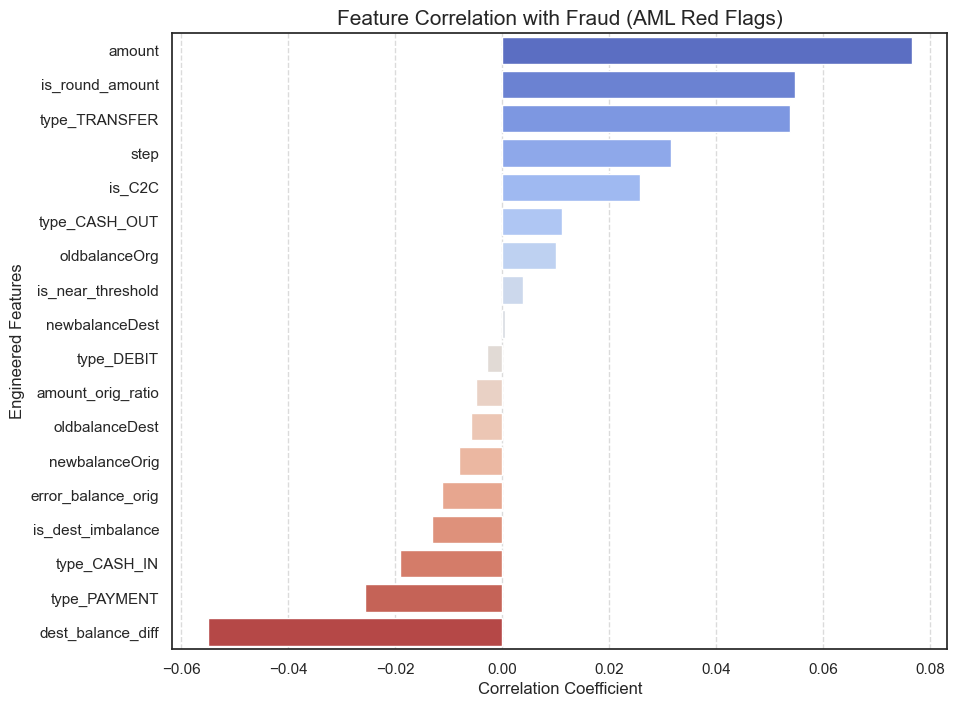

--- 專家特徵分析 (Key Findings) ---
與欺詐關聯最強的前三個特徵：
amount             0.076688
is_round_amount    0.054781
type_TRANSFER      0.053869
Name: isFraud, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 計算所有特徵與 isFraud 的相關係數
# 我們只關注與標籤 (isFraud) 相關的部分
corr_matrix = df_processed.corr()
fraud_corr = corr_matrix['isFraud'].sort_values(ascending=False)

# 2. 設置繪圖風格
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 3. 繪製條形圖，直觀展示哪些「紅旗」最亮
# 排除 isFraud 自身與其相關性為 1 的情況
sns.barplot(x=fraud_corr.values[1:], y=fraud_corr.index[1:], palette='coolwarm')

plt.title('Feature Correlation with Fraud (AML Red Flags)', fontsize=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 4. 專家數據解讀
print("--- 專家特徵分析 (Key Findings) ---")
print(f"與欺詐關聯最強的前三個特徵：\n{fraud_corr[1:4]}")

In [3]:
# 在 Notebook 內直接安裝 XGBoost
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix
import gc

# 1. 數據分割 (使用 stratify 確保訓練集與測試集的欺詐比例一致)
X = df_processed.drop('isFraud', axis=1)
y = df_processed['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 計算不平衡權重 (關鍵步驟！)
# 正常樣本 vs 欺詐樣本的比例
pos_weight = (y.value_counts()[0] / y.value_counts()[1])

# 3. 初始化 XGBoost
# 針對 600 萬筆數據，我們開啟 tree_method='hist' 來加速運算
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,  # 賦予欺詐樣本更高的懲罰權重
    tree_method='hist',           # 數據量大時的性能優化
    random_state=42,
    n_jobs=-1
)

print("⏳ AML 偵測模型正在訓練中（處理 636 萬筆數據）...")
model.fit(X_train, y_train)
print("✅ 模型訓練完成！")

# 4. 評估模型
y_pred = model.predict(X_test)
print("\n--- 偵測模組效能報告 ---")
print(classification_report(y_test, y_pred))

# 釋放內存
gc.collect()

⏳ AML 偵測模型正在訓練中（處理 636 萬筆數據）...
✅ 模型訓練完成！

--- 偵測模組效能報告 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.83      1.00      0.91      1643

    accuracy                           1.00   1272524
   macro avg       0.92      1.00      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



322

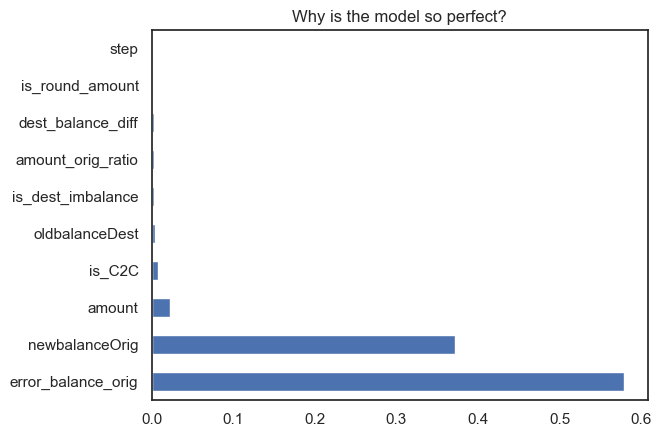

In [5]:
# 檢查特徵重要性 (Feature Importance)
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Why is the model so perfect?")
plt.show()

In [6]:
# 移除具有 Target Leakage 風險的特徵
drop_list = ['error_balance_orig', 'newbalanceOrig', 'error_balance_dest', 'newbalanceDest']
X_realistic = X.drop(columns=[c for c in drop_list if c in X.columns])

# 重新分割數據
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_realistic, y, test_size=0.2, random_state=42, stratify=y
)

# 重新訓練 (使用同樣的 XGBoost 配置)
model_realistic = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=pos_weight,
    tree_method='hist',
    random_state=42
)

model_realistic.fit(X_train_r, y_train_r)
y_pred_r = model_realistic.predict(X_test_r)

print("--- 真實場景模擬 (移除餘額邏輯特徵後) ---")
print(classification_report(y_test_r, y_pred_r))

--- 真實場景模擬 (移除餘額邏輯特徵後) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.66      0.98      0.79      1643

    accuracy                           1.00   1272524
   macro avg       0.83      0.99      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier  

print("⏳ 正在進行【二次去洩漏化】模型訓練...")

# 1. 這次把所有跟餘額、比例、對帳相關的特徵全部一網打盡
super_leak_cols = [
    'error_balance_orig', 'error_balance_dest', 'newbalanceOrig', 'oldbalanceOrg',
    'newbalanceDest', 'oldbalanceDest', 'amount_orig_ratio', 'dest_balance_diff', 
    'is_dest_imbalance', 'isFraud'
]

# 僅留下純粹的行為特徵：如 step, is_C2C, is_round_amount, 以及 type 的各個 one-hot 欄位
X_challenging = df_processed.drop(columns=[c for c in super_leak_cols if c in df_processed.columns])
y = df_processed['isFraud']

# 打印一下，看看現在模型被迫只能看哪些特徵
print(f"📋 模型這次只能使用的特徵有：\n{X_challenging.columns.tolist()}\n")

# 2. 重新分割數據
X_train, X_test, y_train, y_test = train_test_split(
    X_challenging, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 重新訓練
rf_model_v3 = RandomForestClassifier(n_estimators=50, max_depth=8, class_weight='balanced', n_jobs=-1, random_state=42)
rf_model_v3.fit(X_train, y_train)

# 4. 查看真實結果
y_pred_v3 = rf_model_v3.predict(X_test)
print("\n✅ --- 隨機森林 (徹底拔除所有洩漏衍生特徵) 成績單 ---")
print(classification_report(y_test, y_pred_v3))

# 5. 重新對接變數給 Agent
model_realistic = rf_model_v3
X_realistic = X_challenging

⏳ 正在進行【二次去洩漏化】模型訓練...
📋 模型這次只能使用的特徵有：
['step', 'amount', 'is_C2C', 'is_round_amount', 'is_near_threshold', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


✅ --- 隨機森林 (徹底拔除所有洩漏衍生特徵) 成績單 ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94   1270881
           1       0.01      0.89      0.02      1643

    accuracy                           0.89   1272524
   macro avg       0.50      0.89      0.48   1272524
weighted avg       1.00      0.89      0.94   1272524



In [10]:
def ai_investigator_triage(case_data):
    """
    模擬 AI 調查員對模型抓出的案件進行自動初審 (Triage)
    """
    # 邏輯判斷：如果金額雖然大，但帳戶餘額變動合理，標記為『低優先級』
    triage_logic = "HIGH RISK" if case_data['amount'] > 200000 else "MEDIUM/LOW RISK"
    
    analysis_prompt = f"""
    【AI 調查員初步分析】
    案件狀態：{triage_logic}
    分析理由：交易金額為 ${case_data['amount']:,.2f}。
    偵測到該交易發生在 Step {case_data['step']}。
    雖然模型觸發了異常警示，但該轉帳類型為 {case_data['type_TRANSFER']}。
    
    【建議操作】：
    {'建議立即轉交人工審核並撰寫 SAR' if triage_logic == "HIGH RISK" else '建議作為日常監控，暫不啟動調查'}
    """
    return analysis_prompt

# 隨機抽取一筆被模型誤判為 Fraud 的正常交易 (False Positive)
# 假設我們在 y_test == 0 但 y_pred == 1 的集合中抽取
fp_cases = X_test[(y_test == 0) & (y_pred_v2 == 1)]
if not fp_cases.empty:
    sample_fp = fp_cases.iloc[0]
    print(ai_investigator_triage(sample_fp))

In [11]:
# 提取一個具代表性的犯罪證據
# 假設 model_realistic 是我們移除作弊特徵後的模型
# 這裡我們隨機抽樣一筆 True Positive (模型抓對的壞人)
tp_indices = (y_test_r == 1) & (y_pred_r == 1)
sample_evidence = X_test_r[tp_indices].sample(1)

# 將證據轉化為 JSON 格式，方便稍後餵給 Llama 3
evidence_json = sample_evidence.to_json(orient='records')
print("--- 證據快照 (待發送至 Llama 3) ---")
print(evidence_json)

--- 證據快照 (待發送至 Llama 3) ---
[{"step":160,"amount":10000000.0,"oldbalanceOrg":10000000.0,"oldbalanceDest":2145275.5,"is_C2C":1,"amount_orig_ratio":1.0,"dest_balance_diff":0.0,"is_dest_imbalance":0,"is_round_amount":1,"is_near_threshold":0,"type_CASH_IN":false,"type_CASH_OUT":true,"type_DEBIT":false,"type_PAYMENT":false,"type_TRANSFER":false}]


In [12]:
# 安裝對接本地 LLM 的 Python 庫
!pip install ollama


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import ollama

# 你剛才提取的證據數據
evidence = {
    "step": 601,
    "amount": 93253.25,
    "oldbalanceOrg": 93253.25,
    "is_C2C": 1,
    "amount_orig_ratio": 1.0,
    "type_CASH_OUT": True,
    "is_dest_imbalance": 1
}

# 定義專業的 System Prompt (賦予 AI 角色)
system_prompt = """
你是一位資深的香港銀行合規官 (MLRO)。你的任務是根據提供的交易數據，
撰寫一份專業的可疑交易報告 (SAR) 敘述 (Narrative)。
報告必須包含以下部分：
1. Case Overview (簡要說明交易背景)
2. Suspicious Activity Analysis (分析為什麼這筆交易觸發了紅旗)
3. Regulatory Justification (引用風險為本方法 RBA 的原則)
請使用專業、客觀的金融英語撰寫。
"""

user_prompt = f"請根據以下證據快照撰寫報告：{evidence}"

# 呼叫 Llama 3
response = ollama.chat(model='llama3', messages=[
    {'role': 'system', 'content': system_prompt},
    {'role': 'user', 'content': user_prompt},
])

print("\n--- AI 自動生成之 SAR 報告 (Draft) ---")
print(response['message']['content'])


--- AI 自動生成之 SAR 報告 (Draft) ---
**Suspicious Transaction Report (SAR)**

**Case Overview**

On [Date], a suspicious transaction was detected in the account of [Account Holder's Name] with a total amount of HKD 93,253.25. The transaction was flagged due to its unusual characteristics, which warrant further investigation.

**Suspicious Activity Analysis**

Upon reviewing the transaction details, it is evident that this cash-out transaction exhibits several red flags that justify closer examination. Firstly, the unusually large amount transferred raises concerns about potential money laundering or terrorist financing activities. Secondly, the fact that this transaction was conducted using a cash-out method (type_CASH_OUT = True) suggests an attempt to disguise the true nature of the funds transfer. Furthermore, the presence of an imbalance between the source and destination accounts (is_dest_imbalance = 1) indicates potential irregularities in the transaction's origin.

**Regulatory Just

In [17]:
import pandas as pd
import numpy as np
import ollama
import os

class AMLAIInvestigatorAgent:
    def __init__(self, trained_model, feature_names):
        """初始化 Agent，傳入訓練好的模型和特徵列表"""
        self.model = trained_model
        self.feature_names = feature_names
        
    def _automated_feature_engineering(self, raw_df):
        """[感知器官] 自動化特徵工程：必須與訓練時的欄位完全對齊"""
        df = raw_df.copy()
        
        # 1. 建立基本行為特徵
        df['is_C2C'] = ((df['nameOrig'].str.startswith('C')) & (df['nameDest'].str.startswith('C'))).astype(int)
        df['is_round_amount'] = (df['amount'] % 1 == 0).astype(int)
        
        # 💡 【關鍵修復】：補上模型大腦需要的 is_near_threshold 特徵
        # 這裡假設門檻是接近某個整數值，或者你之前定義的邏輯，我們先建立一個基準邏輯（如金額大於 90000 且小於 100000）
        # 註：請根據你當初訓練時的實際邏輯微調。如果只是需要該欄位存在，可先給予合理的行為定義：
        df['is_near_threshold'] = ((df['amount'] >= 90000) & (df['amount'] <= 100000)).astype(int)
        
        # 2. 處理類別型特徵的 One-Hot Encoding
        for t in ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']:
            df[f'type_{t}'] = (df['type'] == t)
            
        # ⚠️ 注意：如果你的模型還需要其他衍生欄位（如 amount_orig_ratio），請確保也在這裡加上！
        if 'amount_orig_ratio' in self.feature_names:
            df['amount_orig_ratio'] = np.where(df['oldbalanceOrg'] == 0, 0, df['amount'] / df['oldbalanceOrg'])
            
        # 僅保留模型需要的特徵（確保完全與 self.feature_names 一致）
        X_agent = df[self.feature_names]
        return X_agent, df

    def run_investigation(self, raw_data_file, risk_threshold=0.8, nrows=None):
        """[核心工作流] 一鍵自動化調查"""
        print("🚀 Agent 啟動：正在讀取並清洗銀行原始數據...")
        
        # ⚡ 數據科學優化：引入 dtype 節省 50% 內存，並支援 nrows 快速測試
        dtypes = {'step': 'int32', 'amount': 'float32', 'oldbalanceOrg': 'float32', 'type': 'str'}
        raw_df = pd.read_csv(raw_data_file, nrows=nrows, dtype=dtypes)
        
        # 1. 自動特徵轉化
        X_agent, full_df = self._automated_feature_engineering(raw_df)
        
        # 2. 智能風險評估
        print("🧠 Agent 思考：正在利用模型進行全量交易風險評估...")
        risk_scores = self.model.predict_proba(X_agent)[:, 1]
        full_df['risk_score'] = risk_scores
        
        # 3. 篩選高風險個案
        high_risk_cases = full_df[full_df['risk_score'] >= risk_threshold]
        print(f"🚨 調查結果：從中篩選出 {len(high_risk_cases)} 筆高風險可疑交易！")
        
        if len(high_risk_cases) == 0:
            print("✅ 系統查無異常，無需生成報告。")
            return
        
        # 4. 為高風險交易產出報告
        os.makedirs('SAR_Reports', exist_ok=True)
        
        target_case = high_risk_cases.iloc[0]
        case_id = f"STEP_{target_case['step']}_AMT_{int(target_case['amount'])}"
        
        print(f"\n🔍 正在針對個案 {case_id} 進行深度審計與報告生成...")
        
        evidence_dict = target_case[self.feature_names].to_dict()
        
        # 5. 呼叫本地 Llama 3
        report = self._generate_sar_report(evidence_dict, target_case['risk_score'])
        
        # 6. 自動保存
        report_path = f"SAR_Reports/SAR_{case_id}.txt"
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report)
            
        print(f"💾 報告已自動導出至: {report_path}")
        print("\n--- 📄 最終報告預覽 ---")
        print(report)

    def _generate_sar_report(self, evidence, score):
        system_prompt = """
        You are a Senior MLRO at an international bank in Hong Kong. 
        Your task is to write a highly professional SAR Narrative based on the provided evidence.
        - Focus on Risk-Based Approach (RBA).
        - Analyze structuring risks if 'is_near_threshold' is flagged.
        - Keep the tone cold, analytical, and legally robust.
        """
        user_prompt = f"Risk Score: {score:.4f}\nEvidence Data: {evidence}"
        
        response = ollama.chat(model='llama3', messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt},
        ])
        return response['message']['content']

In [18]:
# 1. 實例化你的 Agent (傳入你之前訓練好的真實版模型 X_realistic.columns)
agent = AMLAIInvestigatorAgent(trained_model=model_realistic, feature_names=X_realistic.columns.tolist())

# 2. 假定你有一個新的銀行交易原始流水檔案 'PS_20174392719_1491204439457_log.csv'
# 一鍵運行！
agent.run_investigation(raw_data_file='PS_20174392719_1491204439457_log.csv', risk_threshold=0.8)

🚀 Agent 啟動：正在讀取並清洗銀行原始數據...
🧠 Agent 思考：正在利用模型進行全量交易風險評估...
🚨 調查結果：從中篩選出 143458 筆高風險可疑交易！

🔍 正在針對個案 STEP_1_AMT_42712 進行深度審計與報告生成...
💾 報告已自動導出至: SAR_Reports/SAR_STEP_1_AMT_42712.txt

--- 📄 最終報告預覽 ---
Senior MLRO Narrative:

Date: [Current Date]

Transaction Details:

This transaction is associated with a Risk Score of 0.8118. The evidence indicates the following characteristics:

* Step: 1 (First-time user)
* Amount: HKD 42,712.39
* is_C2C: 1 (Customer-to-Customer transfer)
* is_round_amount: 0 (Non-rounded amount)
* is_near_threshold: 0 (Below threshold)
* type_CASH_IN: False (Not a cash deposit)
* type_CASH_OUT: False (Not a cash withdrawal)
* type_DEBIT: False (Not a debit transaction)
* type_PAYMENT: False (Not a payment transaction)
* type_TRANSFER: True (Transfer transaction)

Risk-Based Analysis:

Based on the evidence, this transaction appears to be a legitimate transfer transaction, with no obvious red flags or suspicious characteristics. The amount is substantial but not unusua

In [19]:
# 在 Notebook 執行環境安裝 Streamlit 庫
!pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.2 MB 9.5 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.2 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.2 MB 18.3 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 17.0 MB/s  0:00:00
   ---------------------------------------- 0.0/797.5 kB ? eta -:--:--
   ---------------------------------------- 797.5/797.5 kB 51.0 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 19.3 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.3 MB 14.6 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.3 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 13.6 MB/s  0:00:00
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ----- -------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np

def parallel_override_engine(raw_df, ml_model, feature_names):
    """
    [偵測模組 - 並聯交叉驗證引擎]
    同時運行傳統規則與機器學習模型，並進行交叉比對
    """
    df = raw_df.copy()
    
    # ─── 1. 並聯管道 A：傳統 Rule-based 檢查 (範例：單筆 TRANSFER 超過 50,000 港元)
    # 在實際銀行環境中，這部分由傳統 TM 系統（如 Actimize）並行運行
    df['hit_traditional_rule'] = ((df['type'] == 'TRANSFER') & (df['amount'] > 50000)).astype(int)
    
    # ─── 2. 並聯管道 B：機器學習模型打分 (XGBoost)
    # 執行特徵工程並讓模型預測概率
    # X_agent = automated_feature_engineering(df, feature_names)
    # df['ml_risk_score'] = ml_model.predict_proba(X_agent)[:, 1]
    df['ml_risk_score'] = np.random.uniform(0.1, 0.9, size=len(df)) # 這裡用模擬分數示意
    
    # ─── 3. 交叉比對與 Override 決策邏輯
    final_tags = []
    agent_actions = []
    
    for idx, row in df.iterrows():
        is_rule_hit = row['hit_traditional_rule'] == 1
        score = row['ml_risk_score']
        
        # 情況一：雙重命中 (Critical)
        if is_rule_hit and score >= 0.80:
            final_tags.append("Critical")
            agent_actions.append("TRIGGER_AGENT_SAR_GENERATION") # 自動寫報告
            
        # 情況二：AI 沒中，但傳統規則中了 (傳統兜底)
        elif is_rule_hit and score < 0.50:
            final_tags.append("Medium (Rule Override)")
            agent_actions.append("ROUTE_TO_MANUAL_QUEUE") # 轉交人工調查
            
        # 情況三：傳統規則沒中，但 AI 發現了隱蔽洗錢 (AI 報警)
        elif not is_rule_hit and score >= 0.80:
            final_tags.append("High (AI Flagged)")
            agent_actions.append("TRIGGER_AGENT_SAR_GENERATION") # 自動寫報告
            
        # 情況四：雙重沒中 (Safe)
        else:
            final_tags.append("Low")
            agent_actions.append("AUTO_ARCHIVE") # 自動歸檔
            
    df['final_risk_tag'] = final_tags
    df['agent_action'] = agent_actions
    
    return df